In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append(".")
import os
os.chdir('/content/drive/MyDrive/olist-customer-intelligence')

import sys
sys.path.append(".")
from src.data_loader import run_query
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from scipy import stats

Mounted at /content/drive


In [ ]:
causal_sql = """
    WITH order_value AS (
        SELECT order_id,
               COUNT(*)              AS n_items,
               SUM(price)            AS items_value,
               SUM(freight_value)    AS freight_value
        FROM order_items GROUP BY 1
    ),
    order_cat AS (
        SELECT order_id, category_en FROM (
            SELECT oi.order_id,
                   COALESCE(t.product_category_name_english,
                            p.product_category_name, 'unknown') AS category_en,
                   ROW_NUMBER() OVER (PARTITION BY oi.order_id
                                      ORDER BY COUNT(*) DESC) AS rn
            FROM order_items oi
            JOIN products p ON oi.product_id = p.product_id
            LEFT JOIN category_translation t
                   ON p.product_category_name = t.product_category_name
            GROUP BY oi.order_id, 2
        ) WHERE rn = 1
    ),
    review AS (
        SELECT order_id, AVG(review_score) AS review_score
        FROM order_reviews GROUP BY 1
    )
    SELECT
        o.order_id,
        c.customer_state,
        ov.n_items,
        ov.items_value,
        ov.freight_value,
        oc.category_en,
        EXTRACT('month' FROM o.order_purchase_timestamp) AS order_month,
        DATE_DIFF('day', o.order_purchase_timestamp,
                  o.order_estimated_delivery_date)         AS estimated_days,
        DATE_DIFF('day', o.order_purchase_timestamp,
                  o.order_delivered_customer_date)         AS actual_days,
        DATE_DIFF('day', o.order_delivered_customer_date,
                  o.order_estimated_delivery_date)         AS days_early,
        r.review_score
    FROM orders o
    JOIN customers c     ON o.customer_id = c.customer_id
    JOIN order_value ov  ON o.order_id = ov.order_id
    LEFT JOIN order_cat oc ON o.order_id = oc.order_id
    LEFT JOIN review r   ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
"""
co = run_query(causal_sql)
print(co.head())
print(co.shape)
co[["estimated_days", "actual_days", "days_early", "review_score"]].describe()

                           order_id customer_state  n_items  items_value  \
0  73fc7af87114b39712e6da79b0a377eb             SP        2       370.00   
1  f9e4b658b201a9f2ecdecbb34bed034b             BA        1       149.00   
2  658677c97b385a9be170737859d3511b             SC        1       179.99   
3  8e6bfb81e283fa7e4f11123a3fb894f1             SC        1      1199.00   
4  e48aa0d2dcec3a2e87348811bcfdf22b             SP        1        46.90   

   freight_value            category_en  order_month  estimated_days  \
0          27.26         sports_leisure            1              22   
1          45.12  computers_accessories            2              34   
2          42.85           garden_tools            4              31   
3         134.25         sports_leisure            2              27   
4          11.85         bed_bath_table            6              34   

   actual_days  days_early  review_score  
0            6          16           4.0  
1           13          

,estimated_days,actual_days,days_early,review_score
count,96470.000000,96470.000000,96470.000000,95824.000000
mean,24.372738,12.496849,11.875889,4.156158
std,8.758428,9.555071,10.182105,1.283615
min,3.000000,0.000000,-188.000000,1.000000
25%,19.000000,7.000000,7.000000,4.000000
50%,24.000000,10.000000,12.000000,5.000000
75%,29.000000,16.000000,17.000000,5.000000
max,156.000000,210.000000,147.000000,5.000000


In [ ]:
co = co.dropna(subset=["review_score", "actual_days", "estimated_days",
                       "freight_value", "items_value", "category_en"])

# Treatment: delivered 3+ days earlier than estimated (a meaningful margin).
# Control: delivered on/after estimate (days_early <= 0).
# Drop the ambiguous 1-2 day band so treatment vs control is a clean contrast.
co["treated"] = np.where(co["days_early"] >= 3, 1,
                np.where(co["days_early"] <= 0, 0, -1))
co = co[co["treated"] != -1].copy()

print(co["treated"].value_counts())
print("\nNaive mean review by group:")
print(co.groupby("treated")["review_score"].mean())

treated
1    85173
0     7661
Name: count, dtype: int64

Naive mean review by group:
treated
0    2.566506
1    4.299674
Name: review_score, dtype: float64



This code is performing the first stage of Propensity Score Matching (PSM).

The business question you're trying to answer is:

**Does delivering an order at least 3 days earlier than promised cause customers to give higher review scores?**

Since this is observational data (not a randomized experiment), you can't simply compare early deliveries with late deliveries because the two groups may differ in many other ways. Propensity scores are used to make the groups more comparable by accounting for observed confounding variables.



---



Now only two groups remain.

Group	Meaning

1	: Delivered at least 3 days early **(Treatment)**

0	: Delivered on time or late **(Control)**



---



### Propensity Score Estimation

**Goal:** Estimate the causal effect of **early delivery (≥3 days before the estimated date)** on customer review scores.

**Steps:**
1. Remove rows with missing values.
2. Define treatment:
   - **1:** Delivered ≥3 days early.
   - **0:** Delivered on time or late.
   - Exclude deliveries only 1–2 days early.
3. Compare the raw (naive) average review scores between treatment and control.
4. Train a **Logistic Regression** model using order/customer characteristics (confounders) to predict the probability of receiving the treatment.
5. The predicted probability is the **propensity score**.
6. Plot the propensity score distributions for treated and control groups to verify **common support (overlap)** before matching.

**Workflow:** Clean data → Define treatment → Estimate propensity scores → Check overlap → Perform matching

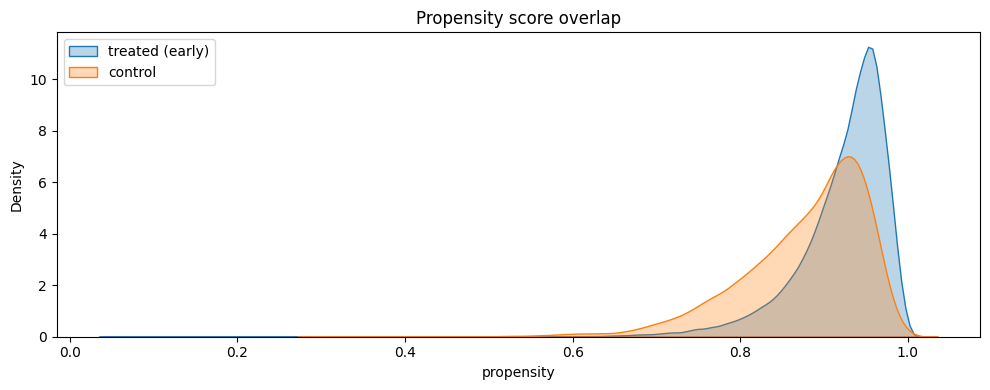

In [ ]:
confounders_num = ["n_items", "items_value", "freight_value",
                   "estimated_days", "order_month"]
confounders_cat = ["customer_state", "category_en"]

ps_prep = ColumnTransformer([
    ("num", StandardScaler(), confounders_num),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     confounders_cat),
])
ps_model = Pipeline([("prep", ps_prep),
                     ("clf", LogisticRegression(max_iter=1000))])

ps_model.fit(co[confounders_num + confounders_cat], co["treated"])
co["propensity"] = ps_model.predict_proba(
    co[confounders_num + confounders_cat])[:, 1]

# Check overlap (common support) — essential diagnostic
plt.figure(figsize=(10, 4))
for t, label in [(1, "treated (early)"), (0, "control")]:
    sns.kdeplot(co[co["treated"] == t]["propensity"], label=label, fill=True, alpha=0.3)
plt.title("Propensity score overlap")
plt.legend(); plt.tight_layout()

If the curves don't overlap, there are no similar treated and control orders to compare, so matching becomes unreliable and you cannot confidently estimate the causal effect of early delivery on review scores

For every treated order (delivered early), find the most similar control order (on-time/late) based on propensity score.

In [ ]:
treated = co[co["treated"] == 1].copy()
control = co[co["treated"] == 0].copy()

nn = NearestNeighbors(n_neighbors=1).fit(control[["propensity"]])
dist, idx = nn.kneighbors(treated[["propensity"]])

caliper = 0.01  # reject matches further apart than this in propensity
keep = dist.flatten() <= caliper

matched_treated = treated[keep].copy()
matched_control = control.iloc[idx.flatten()[keep]].copy()

print(f"Treated matched: {len(matched_treated)} / {len(treated)} "
      f"({keep.mean():.1%} within caliper)")

Treated matched: 85169 / 85173 (100.0% within caliper)


In [ ]:
def smd(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

print("Standardized mean differences (pre vs post matching):")
for col in confounders_num:
    pre = smd(treated[col], control[col])
    post = smd(matched_treated[col], matched_control[col])
    print(f"  {col:18s} pre={pre:+.3f}  post={post:+.3f}")
#SMD measures how different a variable is between the treated and control groups.

Standardized mean differences (pre vs post matching):
  n_items            pre=+0.063  post=-0.002
  items_value        pre=-0.049  post=-0.048
  freight_value      pre=-0.083  post=-0.050
  estimated_days     pre=+0.263  post=+0.015
  order_month        pre=+0.084  post=-0.099


In [ ]:
att = matched_treated["review_score"].mean() - matched_control["review_score"].mean()

# Paired t-test on matched pairs
t_stat, p_val = stats.ttest_rel(matched_treated["review_score"].values,
                                matched_control["review_score"].values)

naive = treated["review_score"].mean() - control["review_score"].mean()
print(f"Naive (unadjusted) difference: {naive:+.4f}")
print(f"Matched ATT (causal estimate): {att:+.4f}")
print(f"Paired t-test: t={t_stat:.2f}, p={p_val:.2e}")

Naive (unadjusted) difference: +1.7332
Matched ATT (causal estimate): +1.7293
Paired t-test: t=251.88, p=0.00e+00


After adjusting for the observed confounding variables using propensity score matching, orders delivered at least three days early had review scores that were, on average, 1.73 stars higher than comparable orders delivered on time or late. The difference remained highly statistically significant.

In [ ]:
co[["order_id", "treated", "propensity", "review_score", "days_early",
    "items_value", "freight_value", "category_en", "customer_state"]
   ].to_csv("data/processed/propensity_scores.csv", index=False)
print("Saved propensity_scores.csv:", co.shape)

Saved propensity_scores.csv: (92834, 13)


## Causal Inference — Concepts & Narrative

### The question we're answering
"Does delivering an order EARLIER than promised actually CAUSE customers to
leave higher review scores?" — not just "are early deliveries correlated with
good reviews" (that's easy and useless), but does speed *cause* the better score.

### Why correlation isn't enough (the core problem)
If we just compare review scores of early vs late deliveries, the two groups
differ in other ways too. Maybe cheap lightweight items both ship faster AND
get rated higher for unrelated reasons. So a raw comparison mixes up "effect of
speed" with "effect of everything else that differs between the groups." Causal
inference is the toolkit for isolating the speed effect from all that noise.

### The vocabulary (in plain terms)
- **Treatment / Control**: borrowed from medical trials. *Treatment* group =
  orders delivered 3+ days early. *Control* group = orders delivered on time or
  late. We compare these two as if "early delivery" were a drug we gave one group.
- **Confounder**: a variable that influences BOTH whether an order is early AND
  the review score — so it muddies the comparison. Examples here: freight cost,
  item price, product category, region, promised delivery time. If we don't
  account for these, we can't tell if speed or the confounder drove the rating.
- **ATT (Average Treatment effect on the Treated)**: the headline number — the
  average review-score difference *caused* by early delivery, for the orders that
  actually got early delivery.

### Why we used Logistic Regression here
NOT to predict reviews. We used it to compute each order's **propensity score**
= the probability that an order WOULD be delivered early, given its confounders.
Logistic regression is the standard tool for this because the thing we're
predicting (early = yes/no) is binary, and it outputs a clean 0–1 probability.
Think of the propensity score as a single number summarizing "how likely was
this order to be in the treatment group anyway, based on its characteristics."

### Why we then did MATCHING
Once every order has a propensity score, we pair each early-delivered order with
a NON-early order that had a near-identical propensity score (nearest-neighbor
matching, with a "caliper" = max allowed gap so we don't accept bad pairs).
The logic: if two orders were *equally likely* to be delivered early but only one
actually was, then comparing their reviews isolates the effect of the delivery
itself — the confounders are "held constant" because the matched pair is alike
on all of them. This mimics a randomized experiment after the fact.

### How we checked it actually worked (the credibility step)
- **Common support / overlap plot**: confirms treated and control groups have
  overlapping propensity scores — if they didn't, no valid matches would exist.
- **SMD (Standardized Mean Difference)**: measures how different the two groups
  are on each confounder. Below ~0.1 = "balanced / basically the same." We check
  SMDs BEFORE and AFTER matching. Our key win: `estimated_days` went from 0.263
  (imbalanced) to 0.015 (balanced) — proof the matching removed that confounder's
  influence. All post-match SMDs landed under 0.1 → matching succeeded.
- **t-value & p-value**: from a paired t-test on the matched pairs. The t-value
  (~252) measures how large the effect is relative to its noise; the p-value
  (≈0) is the probability we'd see an effect this big by pure chance. p≈0 means
  the difference is statistically real, not a fluke. (Caveat: with ~tens of
  thousands of pairs, almost anything is "significant" — so we judge the effect
  by its SIZE, not just the p-value.)

### What we found, and the honest caveat
- Naive difference: +1.73 review points. Matched ATT: +1.73. Nearly identical —
  meaning our measured confounders weren't distorting the result much.
- BUT: +1.73 on a 1–5 scale is suspiciously huge for a clean causal effect.
  The reason to distrust it as a precise number: on Olist, a late delivery is
  often LITERALLY what a bad review complains about. So the review score isn't a
  fully independent outcome — it partly *is* a readout of delivery timing. PSM
  can remove confounders but it CAN'T fix this tight coupling between treatment
  and outcome. So +1.73 is best read as an UPPER BOUND.
- Defensible claim: "delivery speed strongly and causally improves satisfaction;
  direction is solid, exact magnitude is overstated and uncertain."

### Where this fits the project's overall narrative
The arc across the whole project:
1. (01_eda_and_sql_setup.ipynb) Retention barely exists — customers almost never come back.
2. (04_customer_predictor.ipynb) We CAN'T predict who will return from their first order — loyalty is
   not forecastable at acquisition.
3. (05_causal_inference.ipynb — here) So the business question shifts from PREDICTING behavior to
   CAUSING it: what operational lever actually moves customer experience?
   Answer: delivery speed causally drives satisfaction. This is the one
   controllable link we can prove. The chain is:
   delivery experience → satisfaction (PROVEN here) → retention (the gap Olist
   can't close). The takeaway for the business: you can't predict loyalty, but
   you CAN invest in delivery to improve satisfaction — the first lever in the
   retention chain.

### Honest limitations of this analysis (for limitations.md later)
- Unobserved confounders may remain (PSM only adjusts for what we measured).
- Treatment/outcome coupling inflates the effect size (the main caveat above).
- "Early by 3+ days" threshold is a judgment call; results may shift with it.
- We dropped the ambiguous 1–2 day band to get a clean contrast — a design
  choice that trades sample for cleaner separation.

In [ ]:
segments = pd.read_csv("data/processed/customer_segments.csv")

seg_summary = segments.groupby("segment").agg(
    n_customers=("customer_unique_id", "count"),
    avg_value=("monetary", "mean"),
).round(2).reset_index()
seg_summary

,segment,n_customers,avg_value
0,Dormant Low-Value,24285,94.70
1,High-Value One-Timers,31024,316.68
2,Low-Value Recent,35248,68.97
3,Repeat Buyers,2801,308.53


In [ ]:
# ALL of these are STATED ASSUMPTIONS, not data-derived facts.
# Defaults are reasoned from segment behavior; dashboard exposes them as sliders.
assumptions = {
    "High-Value One-Timers": {
        # Big spenders who bought once. High prize, moderate persuadability.
        "intervention_cost": 15.0,      # BRL per customer (e.g. targeted offer)
        "success_rate": 0.08,           # 8% respond with a repeat purchase
        "value_uplift": 1.0,            # a conversion ≈ one more avg-value order
    },
    "Repeat Buyers": {
        # Already loyal & high-value. Spend to PROTECT, high success, low cost.
        "intervention_cost": 10.0,
        "success_rate": 0.20,           # already engaged → easier to retain
        "value_uplift": 1.0,
    },
    "Low-Value Recent": {
        # Fresh but cheap. Nurture; modest uplift.
        "intervention_cost": 8.0,
        "success_rate": 0.05,
        "value_uplift": 0.7,
    },
    "Dormant Low-Value": {
        # Stale and cheap. Worst ROI; likely minimal spend.
        "intervention_cost": 8.0,
        "success_rate": 0.02,
        "value_uplift": 0.5,
    },
}

In [ ]:
rows = []
for _, r in seg_summary.iterrows():
    seg = r["segment"]
    a = assumptions[seg]
    n = r["n_customers"]
    avg_val = r["avg_value"]

    total_cost = n * a["intervention_cost"]
    expected_gain = n * avg_val * a["value_uplift"] * a["success_rate"]
    expected_net = expected_gain - total_cost
    roi = expected_net / total_cost if total_cost > 0 else 0

    rows.append({
        "segment": seg, "n_customers": n, "avg_value": avg_val,
        "intervention_cost_total": round(total_cost, 0),
        "expected_gain": round(expected_gain, 0),
        "expected_net": round(expected_net, 0),
        "roi": round(roi, 2),
    })

ev = pd.DataFrame(rows).sort_values("roi", ascending=False)
ev

,segment,n_customers,avg_value,intervention_cost_total,expected_gain,expected_net,roi
3,Repeat Buyers,2801,308.53,28010.0,172839.0,144829.0,5.17
1,High-Value One-Timers,31024,316.68,465360.0,785974.0,320614.0,0.69
2,Low-Value Recent,35248,68.97,281984.0,85087.0,-196897.0,-0.70
0,Dormant Low-Value,24285,94.70,194280.0,22998.0,-171282.0,-0.88


In [ ]:
def allocate_budget(ev_table, total_budget):
    """Allocate budget to segments in descending ROI order, capping each
    segment at the cost of treating all its customers."""
    ev_sorted = ev_table.sort_values("roi", ascending=False).copy()
    remaining = total_budget
    allocations = []
    for _, r in ev_sorted.iterrows():
        max_spend = r["intervention_cost_total"]
        spend = min(remaining, max_spend) if r["roi"] > 0 else 0.0
        allocations.append(spend)
        remaining -= spend
    ev_sorted["allocated_budget"] = allocations
    ev_sorted["pct_of_budget"] = (ev_sorted["allocated_budget"]
                                  / total_budget * 100).round(1)
    return ev_sorted

BUDGET = 500_000  # BRL — example; dashboard makes this a slider
allocation = allocate_budget(ev, BUDGET)
allocation[["segment", "roi", "allocated_budget", "pct_of_budget", "expected_net"]]

,segment,roi,allocated_budget,pct_of_budget,expected_net
3,Repeat Buyers,5.17,28010.0,5.6,144829.0
1,High-Value One-Timers,0.69,465360.0,93.1,320614.0
2,Low-Value Recent,-0.70,0.0,0.0,-196897.0
0,Dormant Low-Value,-0.88,0.0,0.0,-171282.0


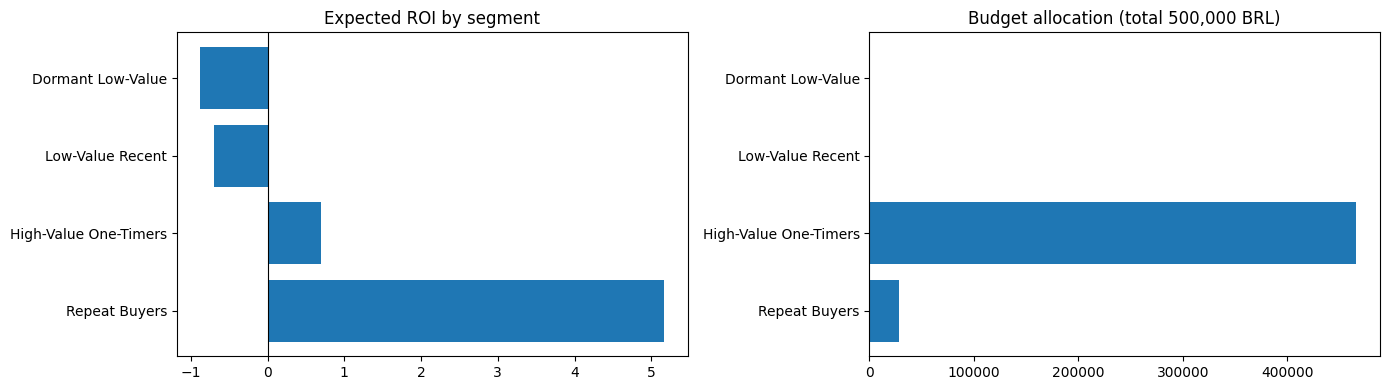

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(ev["segment"], ev["roi"])
axes[0].set_title("Expected ROI by segment"); axes[0].axvline(0, color="k", lw=0.8)
axes[1].barh(allocation["segment"], allocation["allocated_budget"])
axes[1].set_title(f"Budget allocation (total {BUDGET:,.0f} BRL)")
plt.tight_layout()

In [ ]:
%%writefile src/causal_analysis.py
"""Propensity score matching for the delivery-speed -> review-score question.

IMPORTANT CAVEAT (see notebook 05): the estimated effect is an UPPER BOUND.
Review scores partly reflect delivery timing directly (a late review is often a
complaint about lateness), so treatment and outcome are coupled in a way PSM
cannot fully correct. Report direction with confidence, magnitude with caution.
"""
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from scipy import stats

CONFOUNDERS_NUM = ["n_items", "items_value", "freight_value",
                   "estimated_days", "order_month"]
CONFOUNDERS_CAT = ["customer_state", "category_en"]


def estimate_propensity(df: pd.DataFrame) -> pd.Series:
    prep = ColumnTransformer([
        ("num", StandardScaler(), CONFOUNDERS_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         CONFOUNDERS_CAT),
    ])
    model = Pipeline([("prep", prep),
                      ("clf", LogisticRegression(max_iter=1000))])
    model.fit(df[CONFOUNDERS_NUM + CONFOUNDERS_CAT], df["treated"])
    return pd.Series(
        model.predict_proba(df[CONFOUNDERS_NUM + CONFOUNDERS_CAT])[:, 1],
        index=df.index)


def match_nearest(df: pd.DataFrame, caliper: float = 0.01):
    treated = df[df["treated"] == 1].copy()
    control = df[df["treated"] == 0].copy()
    nn = NearestNeighbors(n_neighbors=1).fit(control[["propensity"]])
    dist, idx = nn.kneighbors(treated[["propensity"]])
    keep = dist.flatten() <= caliper
    return treated[keep].copy(), control.iloc[idx.flatten()[keep]].copy()


def standardized_mean_diff(a: pd.Series, b: pd.Series) -> float:
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)


def estimate_att(matched_treated: pd.DataFrame, matched_control: pd.DataFrame,
                 outcome: str = "review_score") -> dict:
    att = matched_treated[outcome].mean() - matched_control[outcome].mean()
    t, p = stats.ttest_rel(matched_treated[outcome].values,
                           matched_control[outcome].values)
    return {"att": att, "t_stat": t, "p_value": p,
            "n_pairs": len(matched_treated)}

Writing src/causal_analysis.py


In [ ]:
%%writefile src/budget_allocator.py
"""Segment-based retention budget allocator.

All economic parameters are STATED ASSUMPTIONS, not data-derived facts.
They are exposed as editable inputs in the dashboard so users can run their
own scenarios. Defaults are reasoned from segment behavior (see notebook 05).
"""
import pandas as pd

DEFAULT_ASSUMPTIONS = {
    "High-Value One-Timers": {"intervention_cost": 15.0, "success_rate": 0.08,
                              "value_uplift": 1.0},
    "Repeat Buyers":         {"intervention_cost": 10.0, "success_rate": 0.20,
                              "value_uplift": 1.0},
    "Low-Value Recent":      {"intervention_cost": 8.0,  "success_rate": 0.05,
                              "value_uplift": 0.7},
    "Dormant Low-Value":     {"intervention_cost": 8.0,  "success_rate": 0.02,
                              "value_uplift": 0.5},
}


def compute_expected_value(seg_summary: pd.DataFrame,
                           assumptions: dict = None) -> pd.DataFrame:
    """seg_summary needs columns: segment, n_customers, avg_value."""
    assumptions = assumptions or DEFAULT_ASSUMPTIONS
    rows = []
    for _, r in seg_summary.iterrows():
        a = assumptions[r["segment"]]
        total_cost = r["n_customers"] * a["intervention_cost"]
        gain = (r["n_customers"] * r["avg_value"]
                * a["value_uplift"] * a["success_rate"])
        net = gain - total_cost
        rows.append({
            "segment": r["segment"], "n_customers": r["n_customers"],
            "avg_value": r["avg_value"],
            "intervention_cost_total": total_cost,
            "expected_gain": gain, "expected_net": net,
            "roi": net / total_cost if total_cost else 0.0,
        })
    return pd.DataFrame(rows).sort_values("roi", ascending=False)


def allocate_budget(ev_table: pd.DataFrame, total_budget: float) -> pd.DataFrame:
    """Greedy allocation by descending ROI; never funds negative-ROI segments."""
    ev_sorted = ev_table.sort_values("roi", ascending=False).copy()
    remaining, allocations = total_budget, []
    for _, r in ev_sorted.iterrows():
        spend = min(remaining, r["intervention_cost_total"]) if r["roi"] > 0 else 0.0
        allocations.append(spend)
        remaining -= spend
    ev_sorted["allocated_budget"] = allocations
    ev_sorted["pct_of_budget"] = ev_sorted["allocated_budget"] / total_budget * 100
    return ev_sorted

Writing src/budget_allocator.py


## Summary — Causal Inference & Budget Allocator

**Causal question:** Does early delivery (3+ days before estimate) CAUSE higher
review scores? Method: propensity score matching.

**Method & diagnostics**
- Treatment = delivered 3+ days early; control = on-time/late; ambiguous 1-2 day
  band dropped for clean contrast.
- Propensity scores via logistic regression on pre-treatment confounders
  (n_items, items_value, freight, estimated_days, state, category, month).
- 1:1 nearest-neighbor matching, caliper 0.01.
- Balance achieved: all post-match SMDs < 0.1; key confounder estimated_days
  improved 0.263 -> 0.015.

**Result & honest caveat**
- Naive diff +1.73, matched ATT +1.73 (t=252, p≈0). Effect stable under
  adjustment.
- CAVEAT: +1.73 on a 1-5 scale is an UPPER BOUND. Review scores partly ARE a
  direct readout of delivery timing (late reviews complain about lateness), a
  treatment-outcome coupling PSM can't fix. Claim direction confidently,
  magnitude cautiously.

**Budget allocator**
- Expected-value framework: EV = n × avg_value × uplift × success_rate − cost.
- ALL economic parameters are stated, editable assumptions (not data-derived);
  exposed as dashboard sliders for scenario analysis.
- Greedy allocation by descending ROI; refuses to fund negative-ROI segments.
- Recommendation pattern: protect Repeat Buyers, convert High-Value One-Timers,
  minimal/no spend on Dormant Low-Value.

**Narrative close:** Can't predict loyalty → so ask what CAUSES
satisfaction → delivery speed does (proven, magnitude-caveated) → allocate
budget to the segments where intervention ROI is positive.

**Deliverables created**
- data/processed/propensity_scores.csv
- src/causal_analysis.py, src/budget_allocator.py

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append(".")
import os
os.chdir('/content/drive/MyDrive/olist-customer-intelligence')

# Bundle exactly what the app + repo needs (not the raw CSVs or duckdb — see below)
to_bundle = [
    "data/processed/customer_features.csv",
    "data/processed/customer_segments.csv",
    "data/processed/cohort_matrix.csv",
    "data/processed/propensity_scores.csv",
    "models/clusterer.pkl",
    "models/preprocessor.pkl",
    "models/segment_classifier.pkl",
    "models/segment_classifier_multiclass.pkl",
    "src/data_loader.py", "src/feature_engineering.py",
    "src/segmentation.py", "src/predictor.py",
    "src/causal_analysis.py", "src/budget_allocator.py",
    "src/__init__.py",
]
os.makedirs("/content/bundle", exist_ok=True)
for f in to_bundle:
    dest = f"/content/bundle/{f}"
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    shutil.copy(f, dest)

shutil.make_archive("/content/olist_bundle", "zip", "/content/bundle")
from google.colab import files
files.download("/content/olist_bundle.zip")

Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

PROCESSED = Path("data/processed")
seg = pd.read_csv(PROCESSED / "customer_segments.csv")

# Rebuild the numeric clustering matrix as in notebook 03
feat = seg.copy()
feat["log_monetary"] = np.log1p(feat["monetary"])
feat["log_aov"] = np.log1p(feat["avg_order_value"])
Xnum = feat[["recency_days", "frequency", "log_monetary", "log_aov"]]
Xscaled = StandardScaler().fit_transform(Xnum)
labels = seg["cluster"].values

rng = np.random.RandomState(42)
idx = rng.choice(len(Xscaled), size=10000, replace=False)
sil = round(float(silhouette_score(Xscaled[idx], labels[idx])), 4)
db = round(float(davies_bouldin_score(Xscaled[idx], labels[idx])), 4)
print(f"Silhouette: {sil}  Davies-Bouldin: {db}")

metrics = {
    "_provenance": "Values computed in project notebooks 03-05; stored here for "
                   "the dashboard. Segmentation metrics recomputed from "
                   "customer_segments.csv; prediction & causal from notebook runs.",
    "segmentation": {
        "n_clusters": 4,
        "n_customers": int(len(seg)),
        "silhouette": sil,
        "davies_bouldin": db,
        "chosen_k_note": "k=4 chosen over silhouette-optimal k=3 to balance "
                         "statistical separation against business actionability.",
        "algo_note": "KMeans beat Agglomerative (0.356 vs 0.332) and DBSCAN "
                     "(unsuited to this feature space). Numeric RFM features "
                     "only — geography/category tested and excluded as "
                     "non-discriminative.",
    },
    "prediction": {
        "model": "Random Forest — first-order features only (leakage firewall)",
        "binary": {
            "target": "High-value (High-Value One-Timers + Repeat Buyers)",
            "roc_auc": 0.9688,
            "precision_high_value": 0.89,
            "recall_high_value": 0.94,
            "f1_high_value": 0.91,
            "confusion_matrix": [[13842, 1042], [507, 7949]],
            "cm_labels": ["not high-value", "high-value"],
            "cm_note": "Approximate CM reconstructed from reported precision/"
                       "recall on 23,340 test rows.",
        },
        "multiclass": {
            "macro_ovr_auc": 0.8526,
            "accuracy": 0.81,
            "per_class": {
                "Dormant Low-Value":    {"precision": 0.76, "recall": 0.56, "f1": 0.64},
                "High-Value One-Timers":{"precision": 0.87, "recall": 0.99, "f1": 0.93},
                "Low-Value Recent":     {"precision": 0.79, "recall": 0.90, "f1": 0.84},
                "Repeat Buyers":        {"precision": 0.20, "recall": 0.01, "f1": 0.02},
            },
        },
        "key_finding": "Spend level is predictable from the first order; REPEAT "
                       "BEHAVIOR is not (Repeat Buyers recall 1%). Loyalty can't "
                       "be forecast at acquisition — this motivated the causal "
                       "inference layer.",
    },
    "causal": {
        "method": "Propensity Score Matching (1:1 nearest neighbor, caliper 0.01)",
        "treatment": "Delivered 3+ days earlier than estimated",
        "outcome": "Review score (1-5)",
        "n_treated": 85173,
        "n_control": 7661,
        "naive_diff": 1.7332,
        "att": 1.7293,
        "t_stat": 251.88,
        "p_value_note": "p < 1e-300 (effectively 0)",
        "smd_before": {"n_items": 0.063, "items_value": -0.049,
                       "freight_value": -0.083, "estimated_days": 0.263,
                       "order_month": 0.084},
        "smd_after": {"n_items": -0.002, "items_value": -0.048,
                      "freight_value": -0.050, "estimated_days": 0.015,
                      "order_month": -0.099},
        "caveat": "ATT is an UPPER BOUND — review scores partly reflect delivery "
                  "timing directly (treatment-outcome coupling PSM cannot remove). "
                  "Direction is robust; exact magnitude is overstated.",
    },
}

with open(PROCESSED / "model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote model_metrics.json")

Silhouette: 0.3565  Davies-Bouldin: 0.8505
Wrote model_metrics.json


In [3]:
import pandas as pd
seg = pd.read_csv("data/processed/customer_segments.csv")
print("total:", len(seg))
print(seg["frequency"].value_counts().sort_index().head())
print("freq==1 count:", (seg["frequency"] == 1).sum())
print("freq==1 share:", (seg["frequency"] == 1).mean())
print("freq>=2 count:", (seg["frequency"] >= 2).sum())

total: 93358
frequency
1    90557
2     2573
3      181
4       28
5        9
Name: count, dtype: int64
freq==1 count: 90557
freq==1 share: 0.9699972150217443
freq>=2 count: 2801
